<a href="https://colab.research.google.com/github/SsamzSouryuu/python-data-journey/blob/main/Modul14_Capstone_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Bagian 1: Data mentah dan cleaning

import pandas as pd

data = pd.read_csv('data_lab_mentah.csv')

jumlah_baris = len(data)
print(jumlah_baris)

300


In [ ]:
# Cek missing values di tiap kolom ada berapa baris

import pandas as pd

data = pd.read_csv('data_lab_mentah.csv')

data1 = data.isna().sum()
print(data1)

tanggal          0
kode_batch       0
nama_produk      0
shift            0
operator         6
mesin            0
berat_basah      0
berat_kering    12
brix             8
dtype: int64


Berat kering kita pertahankan dengan cara menghitung rata rata dari seluruh berat kering

In [11]:
# Menyuruh python untuk menghitung dan mengisi cell yang kosong dengan mean (berat_kering)

import pandas as pd

data = pd.read_csv('data_lab_mentah.csv')

mean = data['berat_kering'].mean()
data['berat_kering'] = data['berat_kering'].fillna(mean)
print(data['berat_kering'])

data.to_csv('data_lab_kering1.csv', index = False)

0      83.6
1      83.9
2      77.1
3      81.5
4      83.5
       ... 
295    81.6
296    89.3
297    75.6
298    74.8
299    70.0
Name: berat_kering, Length: 300, dtype: float64


In [27]:
# Melihat perbedaan penggunaan mean dan median untuk masalah kolom yang kosong di berat_kering
# Agar bisa menentukan lebih baik menggunakan mean atau median, jika menggunakan mean ternyata jaraknya jauh dari median, maka pilihan yang tepat untuk representatif adalah median.

data = pd.read_csv('data_lab_mentah.csv')

print("Mean berat_kering:", data['berat_kering'].mean())
print("Median berat_kering:", data['berat_kering'].median())
print("Min:", data['berat_kering'].min())
print("Max:", data['berat_kering'].max())

Mean berat_kering: 80.7929652777778
Median berat_kering: 81.05
Min: 31.99
Max: 98.9


In [28]:
# Membuang baris yang HANYA kolom 'brix'-nya kosong

import pandas as pd

data = pd.read_csv('data_lab_kering1.csv')

data1 = data.dropna(subset=['brix'])

data1.to_csv('data_lab_bersih1.csv', index = False)

In [16]:
# Ngecek file baru yang udh di mean dan di buang brixnya.

import pandas as pd

data = pd.read_csv('data_lab_bersih1.csv')

data1 = data.isna().sum()
print(data1)

tanggal         0
kode_batch      0
nama_produk     0
shift           0
operator        6
mesin           0
berat_basah     0
berat_kering    0
brix            0
dtype: int64


In [26]:
# Menghitung berapa baris yang tersisa setelah membuang baris yang kosong (validasi)

import pandas as pd

data = pd.read_csv('data_lab_bersih1.csv')

jumlah_baris = len(data)
print(jumlah_baris)

292


In [17]:
# Mengecek missing values dari brix ada di shift mana, dan missing values berat_kering ada di mesin mana

import pandas as pd

data = pd.read_csv('data_lab_mentah.csv')

# Cek: apa missing value brix numpuk di shift tertentu?
print(data[data['brix'].isna()]['shift'].value_counts())

# Cek: apa missing value berat_kering numpuk di mesin tertentu?
print(data[data['berat_kering'].isna()]['mesin'].value_counts())

shift
Pagi     4
Siang    3
Malam    1
Name: count, dtype: int64
mesin
Mesin-2    7
Mesin-3    4
Mesin-1    1
Name: count, dtype: int64


In [18]:
# Melihat penggunaan mesin dalam produksi, dan melihat shift dimana produksi berlangsung (jumlah)

import pandas as pd

data = pd.read_csv('data_lab_mentah.csv')

print(data['mesin'].value_counts())
print(data['shift'].value_counts())

mesin
Mesin-2    115
Mesin-1    105
Mesin-3     80
Name: count, dtype: int64
shift
Pagi     124
Siang     88
Malam     88
Name: count, dtype: int64


In [24]:
# Menghitung persentase dari mesin yang digunakan dari total 300 batch
# menentukan apakah mesin yang bermasalah karena muncul berat_kering yang kosong

import numpy as np

mesin = np.array([105, 115, 80])

print (mesin/300) #35% menggunakan mesin 1, 38% dari mesin 2, dan 26% dari mesin 3 (Dimasak dengan mesin tsb)

[0.35       0.38333333 0.26666667]


In [25]:
# Menghitung berat_kering yang kosong ditiap mesin

import numpy as np

mesin = np.array([1, 7, 4]) #Mesin 1 ada 1, mesin 2 ada 7, mesin 3 ada 4

print (mesin/12) #8,3% ada di mesin 1, 58% ada di mesin 2, dan 33% ada di mesin 3

[0.08333333 0.58333333 0.33333333]


Data missing values masih terlalu kecil untuk diputuskan apakah ada masalah di mesin 2, dan sebagai tindak lanjut akan dipantau lagi untuk mesin 2. Apakah benar benar ada masalah atau hanya kebetulan. Mesin 2 emang menghasilkan data kosong yang banyak, karena penggunaan yang sering juga

In [30]:
# Bagian 2: Klasifikasi & Statistik

import pandas as pd
data = pd.read_csv('data_lab_bersih1.csv')

kadar_air = data['kadar_air'] = ((data['berat_basah'] - data['berat_kering']) / data['berat_basah']) * 100

def klasifikasi_brix(brix): #Nentuin grade untuk brix
    if brix >= 20:
        return "A"
    elif brix >= 10:
        return "B"
    else:
        return "C"

data['grade'] = data['brix'].apply(klasifikasi_brix) #nyuruh nambah header baru yaitu 'grade', yang terambil dari kolom brix dan mengaplikasikan pada 'def'nentuin grade.
print(data.head(10))


      tanggal kode_batch       nama_produk  shift operator    mesin  \
0  2026-07-01   BTC-0001     Keripik Nanas  Siang     Budi  Mesin-2   
1  2026-07-01   BTC-0002    Keripik Mangga  Siang      NaN  Mesin-1   
2  2026-07-01   BTC-0003    Keripik Nangka   Pagi     Dewi  Mesin-2   
3  2026-07-01   BTC-0004      Keripik Apel  Malam     Budi  Mesin-1   
4  2026-07-01   BTC-0005  Keripik Singkong   Pagi     Dewi  Mesin-1   
5  2026-07-01   BTC-0006    Keripik Mangga  Siang     Budi  Mesin-1   
6  2026-07-01   BTC-0007    Keripik Mangga  Siang     Andi  Mesin-1   
7  2026-07-01   BTC-0008     Keripik Tempe   Pagi     Joko  Mesin-2   
8  2026-07-01   BTC-0009     Keripik Nanas  Malam     Joko  Mesin-2   
9  2026-07-01   BTC-0010    Keripik Pisang  Siang     Rina  Mesin-3   

   berat_basah  berat_kering  brix  kadar_air grade  
0         99.0     83.600000  14.0  15.555556     B  
1         99.7     83.900000  11.0  15.847543     B  
2         95.2     77.100000  18.0  19.012605     B  
3 

In [32]:
# Tail

import pandas as pd
data = pd.read_csv('data_lab_bersih1.csv')

kadar_air = data['kadar_air'] = ((data['berat_basah'] - data['berat_kering']) / data['berat_basah']) * 100

def klasifikasi_brix(brix): #Nentuin grade untuk brix
    if brix >= 20:
        return "A"
    elif brix >= 10:
        return "B"
    else:
        return "C"

data['grade'] = data['brix'].apply(klasifikasi_brix) #nyuruh nambah header baru yaitu 'grade', yang terambil dari kolom brix dan mengaplikasikan pada 'def'nentuin grade.
print(data.tail(10))
data.to_csv('data_lab_bersih2.csv', index = False)


        tanggal kode_batch     nama_produk  shift operator    mesin  \
282  2026-07-30   BTC-0290  Keripik Nangka   Pagi    Fajar  Mesin-1   
283  2026-07-30   BTC-0291  Keripik Mangga  Siang     Rina  Mesin-1   
284  2026-07-30   BTC-0292    Keripik Apel  Malam     Joko  Mesin-3   
285  2026-07-30   BTC-0294   Keripik Nanas  Malam     Andi  Mesin-3   
286  2026-07-30   BTC-0295  Keripik Pisang   Pagi     Budi  Mesin-2   
287  2026-07-30   BTC-0296  Keripik Mangga   Pagi     Dewi  Mesin-2   
288  2026-07-30   BTC-0297  Keripik Mangga   Pagi     Siti  Mesin-1   
289  2026-07-30   BTC-0298  Keripik Mangga  Siang     Siti  Mesin-3   
290  2026-07-30   BTC-0299    Keripik Apel  Siang     Joko  Mesin-3   
291  2026-07-30   BTC-0300  Keripik Nangka  Malam    Fajar  Mesin-2   

     berat_basah  berat_kering  brix  kadar_air grade  
282         91.2     80.792965  16.0  11.411222     B  
283         94.2     79.900000  14.0  15.180467     B  
284        100.0     88.000000  20.0  12.000000   

In [36]:
# Menghitung mean dan std dari kadar_air

import pandas as pd
data = pd.read_csv('data_lab_bersih2.csv')

kadar_air = data['kadar_air'].describe()

print(kadar_air)

count    292.000000
mean      15.458784
std        4.621120
min        8.000000
25%       13.371307
50%       14.975918
75%       16.736966
max       65.000000
Name: kadar_air, dtype: float64


Mean: 15.458784
std: 4.621120
Min: 8.0
Max: 65.0

In [40]:
import pandas as pd

data = pd.read_csv('data_lab_bersih2.csv')

data1 = data['kadar_air'].min()

print (data1)

7.999999999999995


In [41]:
import pandas as pd

data = pd.read_csv('data_lab_bersih2.csv')

data1 = data['kadar_air'].max()

print (data1)

65.00000000000001


Oke berarti min dan max di describe bukan sebagai batas kadar air, tapi emang hasil perhitungan kadar air, yang paling kecil dan paling besar

In [43]:
# Cp dan Cpk

data = pd.read_csv('data_lab_bersih2.csv')

mean = data['kadar_air'].mean()
std = data['kadar_air'].std()

USL = 65   # Batas Atas Spek
LSL = 8  # Batas Bawah Spek

Cp = (USL - LSL) / (6 * std)
Cpk = min((mean - LSL) / (3 * std), (USL - mean) / (3 * std))

print(f"Mean: {mean:.2f}, Std: {std:.2f}")
print(f"Cp: {Cp:.3f}")
print(f"Cpk: {Cpk:.3f}")

Mean: 15.46, Std: 4.62
Cp: 2.056
Cpk: 0.538


Salah karena menggunakan batas atas dan batas bawah dengan angka dimana max dan min dari kasih perhitungan kadar air. kalau LSL/USL diambil dari min/max data sendiri, maka secara otomatis, rentang USL - LSL itu jadi selebar mungkin data kamu bisa nyebar, gak peduli beneran itu standar mutu masuk akal atau enggak. Jadi mengisi USL dan LSL dengan SOP, agar ketahuan mana aja data yang keluar dari USL, LSL. Kalo USL, LSL diisi pake data min,max maka seluruh data akan "aman".

In [42]:
# Cp dan Cpk (versi benar)

data = pd.read_csv('data_lab_bersih2.csv')

mean = data['kadar_air'].mean()
std = data['kadar_air'].std()

USL = 20   # Batas Atas Spek
LSL = 10  # Batas Bawah Spek

Cp = (USL - LSL) / (6 * std)
Cpk = min((mean - LSL) / (3 * std), (USL - mean) / (3 * std))

print(f"Mean: {mean:.2f}, Std: {std:.2f}")
print(f"Cp: {Cp:.3f}")
print(f"Cpk: {Cpk:.3f}")

Mean: 15.46, Std: 4.62
Cp: 0.361
Cpk: 0.328


Dua-duanya di bawah 1,00, ini artinya proses (hipotetis) ini belum capable buat konsisten muat di standar SOP 10-20% itu. Karena std = 4,62 itu cukup besar dibanding lebar spek (20-10 = 10) — datanya nyebar lumayan lebar dibanding "ruang gerak" yang dikasih standar.

In [46]:
# IQR

import pandas as pd

data = pd.read_csv('data_lab_bersih2.csv')

Q1_brix = data['brix'].quantile(0.25) #Hasil batas bawahnya 0
Q3_brix = data['brix'].quantile(0.75) #Hasil batas atasnya 32
IQR_brix = Q3_brix - Q1_brix

batas_bawah_brix = Q1_brix - (1.5 * IQR_brix)
batas_atas_brix = Q3_brix + (1.5 * IQR_brix)
outlier_brix_manual = data[(data['brix'] < 8) | (data['brix'] > 25)]
print(outlier_brix_manual[['kode_batch', 'brix']])

    kode_batch  brix
9     BTC-0010  45.0
109   BTC-0112   3.0


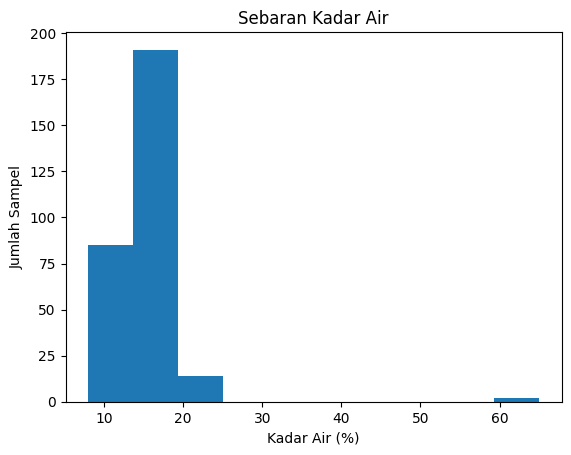

In [47]:
# Bagian 3: Visualisasi
# Histogram

import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('data_lab_bersih2.csv')

plt.hist(data['kadar_air'], bins=10)
plt.xlabel('Kadar Air (%)')
plt.ylabel('Jumlah Sampel')
plt.title('Sebaran Kadar Air')
plt.show()

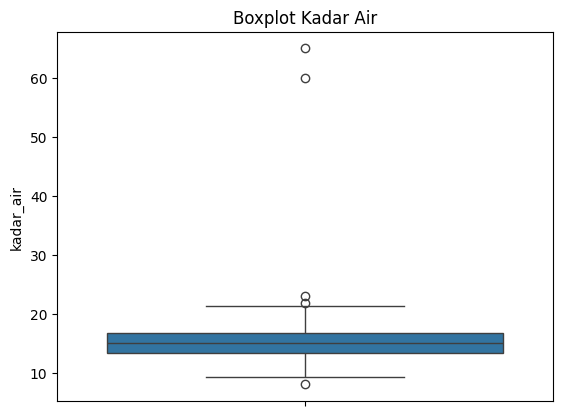

In [48]:
# Boxplot, pengganti IQR manual

import seaborn as sns
import pandas as pd

data = pd.read_csv('data_lab_bersih2.csv')

sns.boxplot(y=data['kadar_air'])
plt.title('Boxplot Kadar Air')
plt.show()

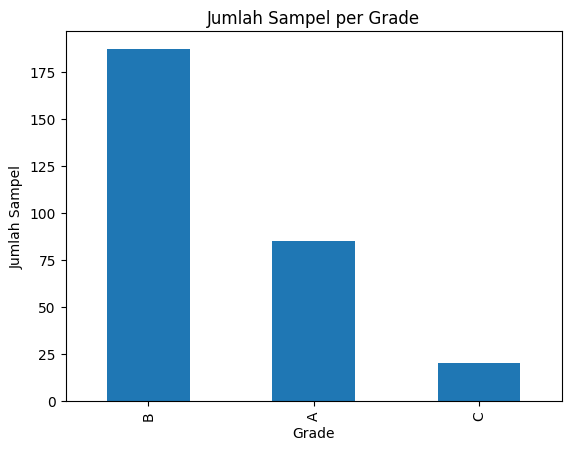

In [49]:
# Bar Chart

import pandas as pd

data = pd.read_csv('data_lab_bersih2.csv')

data['grade'].value_counts().plot(kind='bar')
plt.xlabel('Grade')
plt.ylabel('Jumlah Sampel')
plt.title('Jumlah Sampel per Grade')
plt.show()


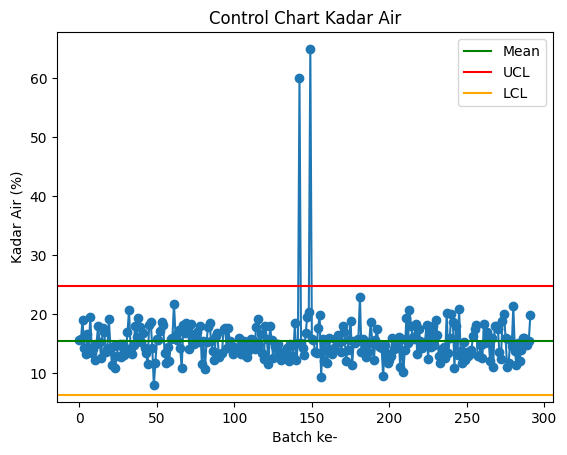

In [54]:
import matplotlib.pyplot as plt
import pandas as pd

data = pd.read_csv('data_lab_bersih2.csv')

mean = data['kadar_air'].mean()
std = data['kadar_air'].std()
UCL = mean + (2 * std)
LCL = mean - (2 * std)

plt.plot(data['kadar_air'], marker = 'o')
plt.axhline(mean, color = 'green', linestyle = '-', label = 'Mean')
plt.axhline(UCL, color = 'red', linestyle = '-', label = 'UCL')
plt.axhline(LCL, color = 'orange', linestyle = '-', label = 'LCL')
plt.xlabel('Batch ke-')
plt.ylabel('Kadar Air (%)')
plt.title('Control Chart Kadar Air')
plt.legend()
plt.show()